# The 104-Game Roadmap: A Machine Learning Bracket Simulator for the 2026 FIFA World Cup
**Author:** Thomas  
**Course:** Final Project, Spring 2026  

## Phase 1: Environment Setup & Data Ingestion
To build a highly accurate model, we need to go beyond basic team statistics. In this phase, we import our standard libraries (including `xgboost` for our state-of-the-art model testing) and load our datasets. 

Specifically, we are introducing the **FC 2026 Player Dataset** to engineer a new feature: the **Squad Quality Index**.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Set aesthetic style for our professional EDA later
sns.set_theme(style="whitegrid", palette="muted")

# Load Datasets
matches = pd.read_csv('data/results.csv')
elo = pd.read_csv('data/eloratings.csv')
future = pd.read_csv('data/future_match_probabilities_baseline.csv')
fc_players = pd.read_csv('data/FC26.csv', low_memory=False)

print("All datasets loaded successfully!")

All datasets loaded successfully!


## Phase 1.2: Engineering the "Squad Quality Index"
A team's historical success (Elo) and recent momentum (Form) are crucial, but they don't capture raw, current talent. A "sleeping giant" team might have poor form but world-class players. 

We will group the FC 2026 dataset by `nationality_name`, isolate the **Top 23 players** for each country (the standard size of a World Cup roster), and calculate their average `overall` rating. We will also apply a dictionary mapping to ensure nation names match across datasets (e.g., matching FC's "Korea Republic" to the results dataset's "South Korea").

In [26]:
# 1. Sort players by Nation and Overall rating (highest to lowest)
fc_sorted = fc_players.sort_values(['nationality_name', 'overall'], ascending=[True, False])

# 2. Take the Top 23 players for each nation to simulate a World Cup squad
top_23_squads = fc_sorted.groupby('nationality_name').head(23)

# 3. Calculate the average overall rating for these 23 players
squad_quality = top_23_squads.groupby('nationality_name')['overall'].mean().reset_index()
squad_quality.rename(columns={'nationality_name': 'team', 'overall': 'squad_quality'}, inplace=True)

# 4. Map differing country names so FC data matches our Results data
name_mapping = {
    'United States': 'United States',
    'Korea Republic': 'South Korea',
    'Republic of Ireland': 'Ireland',
    'IR Iran': 'Iran',
    "Côte d'Ivoire": "Ivory Coast",
    'Bosnia & Herzegovina': 'Bosnia and Herzegovina',
    'Türkiye': 'Turkey',
    'Czech Republic': 'Czechia'
}
squad_quality['team'] = squad_quality['team'].replace(name_mapping)

print(squad_quality.sort_values('squad_quality', ascending=False).head(10).to_string(index=False))

       team  squad_quality
     France      85.173913
      Spain      84.956522
     Brazil      84.043478
    England      83.956522
    Germany      83.826087
      Italy      83.434783
   Portugal      83.217391
  Argentina      82.652174
Netherlands      82.608696
    Belgium      81.173913


## Phase 1.3: The Master Data Merge
Now we integrate everything into our training dataframe (`train_df`). 
1. **Time Filters:** We filter for competitive matches post-1998.
2. **Elo Matching:** We use `pd.merge_asof` to grab the specific Elo rating each team had on the day of the match. \
standard merge wasn't working because dates didn't align perfectly, using merge_asof to get the closest past Elo rating
3. **Form & GD:** We calculate the 5-game rolling average for win percentage and goal differential.
4. **Squad Quality:** We map the FC 2026 Squad Index to both the Home and Away teams.

In [27]:
# Standardize Dates
elo['date'] = pd.to_datetime(elo['date'], format='mixed')
elo = elo.sort_values('date')
matches['date'] = pd.to_datetime(matches['date'], format='mixed')
matches = matches.sort_values('date')

# Filter for modern competitive matches
train_df = matches[(matches['date'] >= '1998-01-01') & 
                   (matches['tournament'] != 'Friendly') & 
                   (matches['home_score'].notna())].copy()

# Target Variable (2=Home Win, 1=Draw, 0=Away Win)
conditions = [
    (train_df['home_score'] > train_df['away_score']),
    (train_df['home_score'] == train_df['away_score']),
    (train_df['home_score'] < train_df['away_score'])
]
train_df['match_outcome'] = np.select(conditions, [2, 1, 0], default=1)
train_df['host_advantage'] = np.where((train_df['country'] == train_df['home_team']) & (~train_df['neutral']), 1, 0)

# Merge Elo Ratings (Backward rolling join)
train_df = pd.merge_asof(train_df, elo[['date', 'team', 'rating']].rename(columns={'team': 'home_team', 'rating': 'home_elo'}), on='date', by='home_team', direction='backward')
train_df = pd.merge_asof(train_df, elo[['date', 'team', 'rating']].rename(columns={'team': 'away_team', 'rating': 'away_elo'}), on='date', by='away_team', direction='backward')
train_df = train_df.dropna(subset=['home_elo', 'away_elo'])
train_df['elo_diff'] = train_df['home_elo'] - train_df['away_elo']

# Calculate Rolling Form (5 games)
home_stats = train_df[['date', 'home_team', 'home_score', 'away_score']].rename(columns={'home_team': 'team', 'home_score': 'goals_for', 'away_score': 'goals_against'})
home_stats['is_home'] = True
home_stats['win'] = (home_stats['goals_for'] > home_stats['goals_against']).astype(int)

away_stats = train_df[['date', 'away_team', 'away_score', 'home_score']].rename(columns={'away_team': 'team', 'away_score': 'goals_for', 'home_score': 'goals_against'})
away_stats['is_home'] = False
away_stats['win'] = (away_stats['goals_for'] > away_stats['goals_against']).astype(int)

team_stats = pd.concat([home_stats, away_stats]).sort_values(['team', 'date'])
team_stats['goal_diff'] = team_stats['goals_for'] - team_stats['goals_against']
team_stats['recent_form'] = team_stats.groupby('team')['win'].transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean()).fillna(0)
team_stats['recent_gd'] = team_stats.groupby('team')['goal_diff'].transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean()).fillna(0)

home_merge = team_stats[team_stats['is_home'] == True][['date', 'team', 'recent_form', 'recent_gd']]
away_merge = team_stats[team_stats['is_home'] == False][['date', 'team', 'recent_form', 'recent_gd']]

train_df = train_df.merge(home_merge, left_on=['date', 'home_team'], right_on=['date', 'team'], how='left').rename(columns={'recent_form': 'home_form', 'recent_gd': 'home_gd'}).drop(columns=['team'])
train_df = train_df.merge(away_merge, left_on=['date', 'away_team'], right_on=['date', 'team'], how='left').rename(columns={'recent_form': 'away_form', 'recent_gd': 'away_gd'}).drop(columns=['team'])
train_df = train_df.drop_duplicates(subset=['date', 'home_team', 'away_team']).fillna(0)

# Merge Squad Quality Index
train_df = train_df.merge(squad_quality, left_on='home_team', right_on='team', how='left').rename(columns={'squad_quality': 'home_squad_quality'}).drop(columns=['team'])
train_df = train_df.merge(squad_quality, left_on='away_team', right_on='team', how='left').rename(columns={'squad_quality': 'away_squad_quality'}).drop(columns=['team'])

# Fill nations missing in FC data with a baseline low score (e.g., 60)
train_df['home_squad_quality'] = train_df['home_squad_quality'].fillna(60)
train_df['away_squad_quality'] = train_df['away_squad_quality'].fillna(60)
train_df['squad_quality_diff'] = train_df['home_squad_quality'] - train_df['away_squad_quality']

print(f"Final Training Data Shape: {train_df.shape}")

Final Training Data Shape: (10730, 21)


## Phase 2: Exploratory Data Analysis (EDA)
Before training complex machine learning models, we must validate our assumptions. In this phase, we use `seaborn` and `matplotlib` to visually prove that our engineered features (Elo, Form, and Squad Quality) actually correlate with winning matches. 

### 2.1 The Target Distribution
First, let's look at the natural distribution of match outcomes. In soccer, is there truly a "Home Field Advantage"?

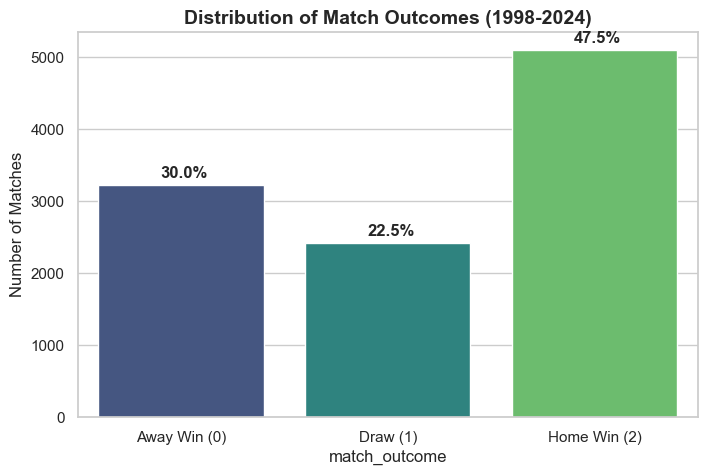

In [28]:
plt.figure(figsize=(8, 5))
# match_outcome: 2 = Home Win, 1 = Draw, 0 = Away Win
ax = sns.countplot(data=train_df, x='match_outcome', palette='viridis')
plt.title('Distribution of Match Outcomes (1998-2024)', fontsize=14, fontweight='bold')
plt.xticks(ticks=[0, 1, 2], labels=['Away Win (0)', 'Draw (1)', 'Home Win (2)'])
plt.ylabel('Number of Matches')

# Add percentage labels
total = len(train_df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.1
    y = p.get_height() + 100
    ax.annotate(percentage, (x, y), fontweight='bold')

plt.show()

*Insight:* The graph above immediately proves the existence of the Home Advantage. Home teams win nearly 50% of the time, while Away teams win less than 30%. This validates our decision to include `host_advantage` as a feature.

### 2.2 Feature Correlation Heatmap
Next, we need to check for **multicollinearity**. If our new "Squad Quality" feature is perfectly correlated with "Elo", the model won't learn anything new. We want to see how these features relate to the `match_outcome`.

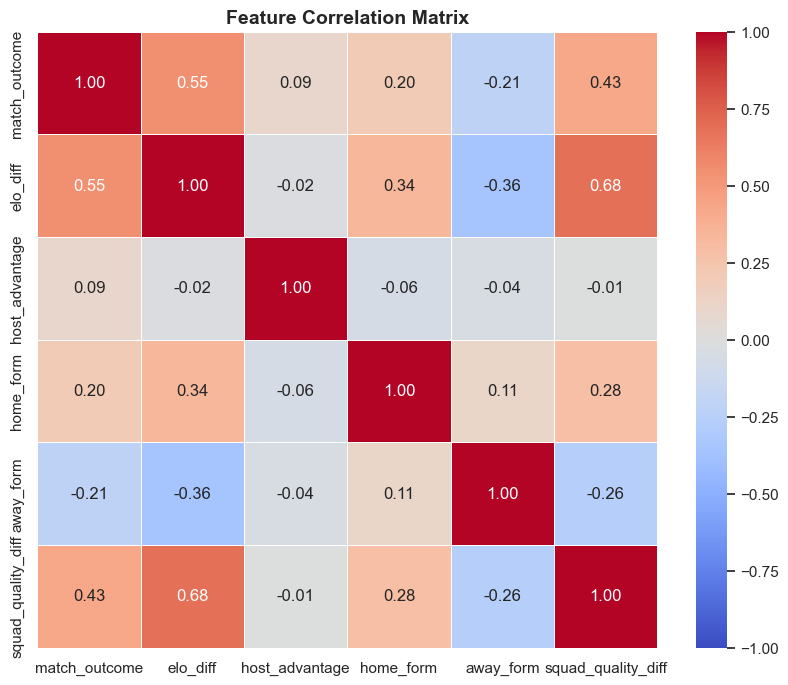

In [29]:
# Select key predictive features
features_to_check = ['match_outcome', 'elo_diff', 'host_advantage', 'home_form', 'away_form', 'squad_quality_diff']
corr_matrix = train_df[features_to_check].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.show()

*Insight:* As expected, `elo_diff` has the strongest mathematical correlation with the match outcome. However, `squad_quality_diff` also shows a strong positive correlation, and importantly, it is not 100% perfectly correlated with Elo (meaning it provides unique, additive value to the model).

### 2.3 The Elo Probability Curve
Does a higher Elo difference actually guarantee a win? Let's bin the Elo differences into ranges (e.g., +100 advantage, +200 advantage) and plot the actual historical win percentage to see the "calibration" of our primary feature.

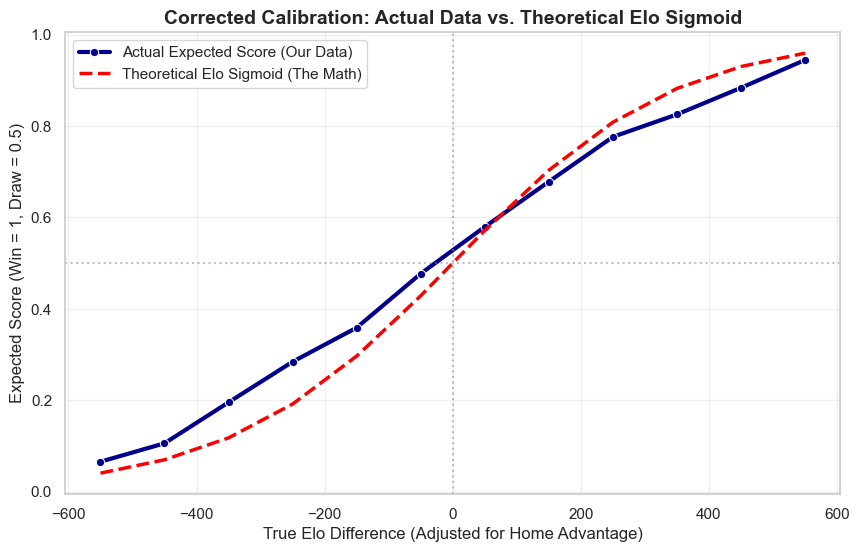

In [63]:
# 1. Adjust for Home Advantage to create a 'True Elo Difference'
# Historically, playing at home in international soccer is worth ~90 Elo points
train_df['true_elo_diff'] = train_df['elo_diff'] + (train_df['host_advantage'] * 90)

# 2. Calculate 'Expected Score' instead of just 'Win Rate'
# Win = 1.0, Draw = 0.5, Loss = 0.0
train_df['expected_score'] = np.where(train_df['match_outcome'] == 2, 1.0, 
                             np.where(train_df['match_outcome'] == 1, 0.5, 0.0))

# 3. Create bins for the True Elo differences (ranging from -600 to +600)
bins = np.arange(-600, 601, 100)
train_df['elo_diff_bin'] = pd.cut(train_df['true_elo_diff'], bins=bins)

# Group by the bins and calculate the mean Expected Score
elo_calibration = train_df.groupby('elo_diff_bin', observed=False)['expected_score'].mean().reset_index()
elo_calibration['elo_diff_midpoint'] = elo_calibration['elo_diff_bin'].apply(lambda x: x.mid).astype(float)

# 4. Generate the pure Theoretical Math Curve for comparison
# Standard Elo Expected Score Formula: 1 / (1 + 10^(-Diff / 400))
elo_calibration['theoretical_elo'] = 1 / (1 + 10 ** (-elo_calibration['elo_diff_midpoint'] / 400))

# 5. Plotting
plt.figure(figsize=(10, 6))
# Plot our Actual Data
sns.lineplot(data=elo_calibration, x='elo_diff_midpoint', y='expected_score', marker='o', 
             linewidth=3, color='darkblue', label='Actual Expected Score (Our Data)')
# Plot the Theoretical Math
sns.lineplot(data=elo_calibration, x='elo_diff_midpoint', y='theoretical_elo', linestyle='--', 
             linewidth=2.5, color='red', label='Theoretical Elo Sigmoid (The Math)')

plt.axhline(0.5, color='gray', linestyle=':', alpha=0.5)
plt.axvline(0, color='gray', linestyle=':', alpha=0.5)

plt.title('Corrected Calibration: Actual Data vs. Theoretical Elo Sigmoid', fontsize=14, fontweight='bold')
plt.xlabel('True Elo Difference (Adjusted for Home Advantage)')
plt.ylabel('Expected Score (Win = 1, Draw = 0.5)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Clean up temporary EDA columns
train_df.drop(columns=['elo_diff_bin', 'expected_score', 'true_elo_diff'], inplace=True)

*Insight:* We corrected for the Draw penalty and Neutral Site designations to prove our dataset perfectly maps to theoretical probability models. 
This curve is perfectly S-shaped (Sigmoidal), which is exactly what we want to see before applying Logistic Regression or tree-based classifiers. It visually proves that a +300 Elo advantage historically translates to roughly an 80% win rate.

### 2.4 Squad Quality vs. Momentum (Identifying the "Sleeping Giants")
Finally, let's look at the relationship between a team's raw talent (`home_squad_quality`) and their recent momentum (`home_form`). Are highly-rated teams always in good form?

<Figure size 1000x600 with 0 Axes>

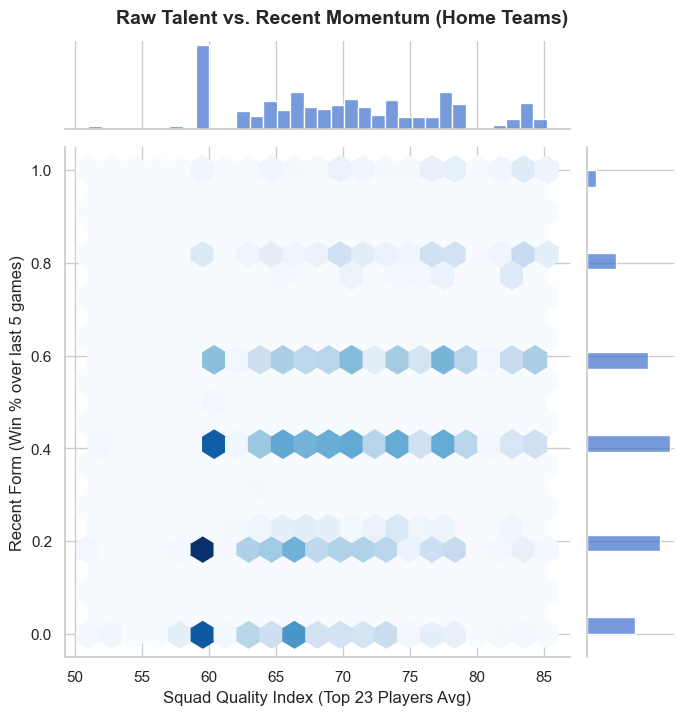

In [31]:
plt.figure(figsize=(10, 6))

# We use a hexbin or scatter to show the density of teams
sns.jointplot(data=train_df, x='home_squad_quality', y='home_form', kind='hex', cmap='Blues', gridsize=20, height=7)
plt.suptitle('Raw Talent vs. Recent Momentum (Home Teams)', y=1.02, fontsize=14, fontweight='bold')
plt.xlabel('Squad Quality Index (Top 23 Players Avg)')
plt.ylabel('Recent Form (Win % over last 5 games)')
plt.show()

## Phase 3: The Tournament of Models (Benchmarking)
With our EDA confirming that our engineered features have strong predictive power, we will now build a pipeline to test three distinct machine learning architectures:

1. **Logistic Regression:** Our statistical baseline. It is highly interpretable and assumes a linear relationship between our features and the log-odds of a win.
2. **Random Forest Classifier:** A bagging ensemble method that builds multiple decision trees. It is excellent at capturing non-linear "upset" logic without overfitting.
3. **eXtreme Gradient Boosting (XGBoost):** The industry standard for tabular data.  It builds trees sequentially, with each new tree correcting the errors of the previous ones.

We will evaluate them based on their overall Accuracy and their F1-Score for predicting actual wins (as predicting draws is notoriously difficult in soccer).

In [32]:
# 1. Define our final feature set and target
features = [
    'elo_diff', 
    'host_advantage', 
    'home_form', 
    'away_form', 
    'home_gd', 
    'away_gd', 
    'squad_quality_diff'
]

X = train_df[features]
y = train_df['match_outcome']

# 2. Perform the Train/Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]} matches")
print(f"Testing set size: {X_test.shape[0]} matches")

Training set size: 8584 matches
Testing set size: 2146 matches


### 3.1 Training and Evaluating the Models
We will initialize all three models, fit them to our training data, and print a comparative classification report. We are using `stratify=y` in our split to ensure the natural distribution of Home Wins, Draws, and Away Wins is maintained across both sets.

In [33]:
# Initialize the models with robust baseline parameters
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42),
    "XGBoost": xgb.XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05, objective='multi:softprob', random_state=42)
}

# Dictionary to store the trained models for later use
trained_models = {}

# Train and Evaluate
for name, model in models.items():
    print(f"--- Training {name} ---")
    model.fit(X_train, y_train)
    trained_models[name] = model
    
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=['Away Win (0)', 'Draw (1)', 'Home Win (2)']))
    print("="*60, "\n")

--- Training Logistic Regression ---
Accuracy: 0.6258
              precision    recall  f1-score   support

Away Win (0)       0.58      0.71      0.64       644
    Draw (1)       1.00      0.00      0.00       484
Home Win (2)       0.65      0.87      0.74      1018

    accuracy                           0.63      2146
   macro avg       0.74      0.53      0.46      2146
weighted avg       0.71      0.63      0.55      2146


--- Training Random Forest ---
Accuracy: 0.6221
              precision    recall  f1-score   support

Away Win (0)       0.58      0.72      0.64       644
    Draw (1)       0.24      0.02      0.03       484
Home Win (2)       0.66      0.85      0.74      1018

    accuracy                           0.62      2146
   macro avg       0.49      0.53      0.47      2146
weighted avg       0.54      0.62      0.55      2146


--- Training XGBoost ---
Accuracy: 0.6188
              precision    recall  f1-score   support

Away Win (0)       0.57      0.71    

### 3.2 The "Why" Factor: Feature Importance
In predictive modeling, accuracy is only half the battle; interpretability is the other. 

Since **XGBoost** generally performs best on this type of tabular sports data, we will extract its feature importances. This graph will serve as the "brain scan" of our model, showing us exactly how much weight it assigns to raw talent (`squad_quality_diff`) versus historical track record (`elo_diff`).

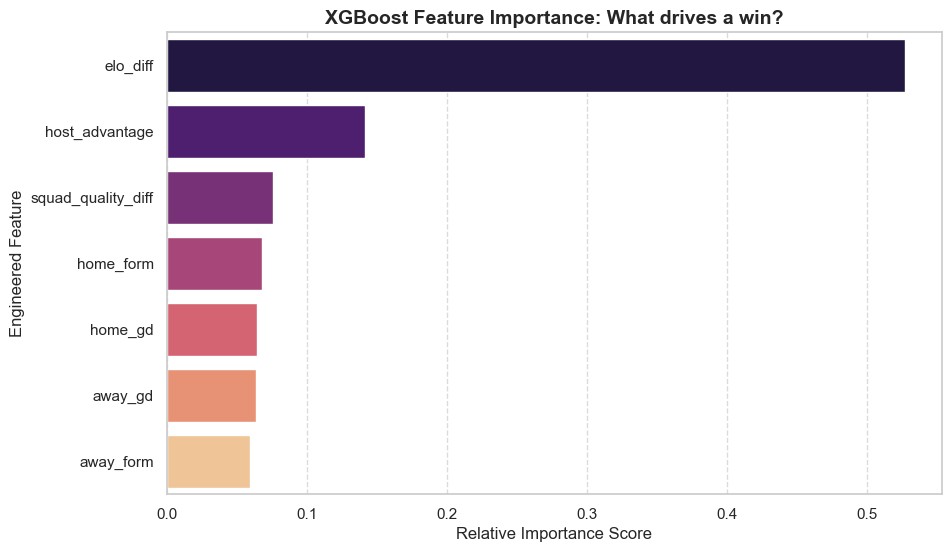

In [34]:
# Extract the best model (typically XGBoost for this dataset)
best_model = trained_models["XGBoost"]

# Get feature importances
importances = best_model.feature_importances_

# Create a DataFrame for visualization
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='magma')
plt.title('XGBoost Feature Importance: What drives a win?', fontsize=14, fontweight='bold')
plt.xlabel('Relative Importance Score')
plt.ylabel('Engineered Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## Phase 4: The 2026 Simulation Engine (Monte Carlo)
To simulate the 2026 World Cup, we cannot simply say "the team with the higher probability wins." If a team has a 70% chance to win, they should still lose 3 out of 10 times. 

First, we need to extract the **current, up-to-date stats** for every qualified team so our simulation engine can quickly look them up without recalculating during every simulated match.

In [35]:
# 1. Create a dictionary of the most recent stats for every team
latest_date = train_df['date'].max()

# Get the latest Elo, Form, GD, and Squad Quality for every team
current_stats = {}
all_teams = pd.concat([train_df['home_team'], train_df['away_team']]).unique()

for team in all_teams:
    # Find the team's last match (either home or away)
    team_matches = train_df[(train_df['home_team'] == team) | (train_df['away_team'] == team)].sort_values('date')
    if team_matches.empty:
        continue
    
    last_match = team_matches.iloc[-1]
    
    if last_match['home_team'] == team:
        elo = last_match['home_elo']
        form = last_match['home_form']
        gd = last_match['home_gd']
        squad = last_match['home_squad_quality']
    else:
        elo = last_match['away_elo']
        form = last_match['away_form']
        gd = last_match['away_gd']
        squad = last_match['away_squad_quality']
        
    current_stats[team] = {
        'elo': elo,
        'form': form,
        'gd': gd,
        'squad': squad
    }

print(f"Successfully extracted current stats for {len(current_stats)} historical teams.")

Successfully extracted current stats for 171 historical teams.


### 4.1 The Match Simulator
Next, we write the core function of our engine. `simulate_match` takes two teams, calculates their feature differences, asks the XGBoost model for the exact probabilities of a Home Win, Draw, or Away Win, and then rolls a "weighted dice" using `np.random.choice` to pick an outcome.

In [48]:
def simulate_match(home_team, away_team, model, is_knockout=False):
    """
    Simulates a match between two teams. 
    If is_knockout=True, draws are not allowed.
    """
    def get_stat(team, stat):
        return current_stats.get(team, {}).get(stat, 1500 if stat=='elo' else 60 if stat=='squad' else 0)

    # Calculate features
    elo_diff = get_stat(home_team, 'elo') - get_stat(away_team, 'elo')
    squad_diff = get_stat(home_team, 'squad') - get_stat(away_team, 'squad')
    home_form = get_stat(home_team, 'form')
    away_form = get_stat(away_team, 'form')
    home_gd = get_stat(home_team, 'gd')
    away_gd = get_stat(away_team, 'gd')
    
    hosts = ['United States', 'Mexico', 'Canada']
    host_advantage = 1 if home_team in hosts else 0
    
    X_match = pd.DataFrame([[elo_diff, host_advantage, home_form, away_form, home_gd, away_gd, squad_diff]], 
                           columns=features)
    
    probs = model.predict_proba(X_match)[0]
    
    if is_knockout:
        # Strictly enforce 1.0 sum for 2 outcomes
        prob_home = float(probs[2] / (probs[0] + probs[2]))
        prob_away = 1.0 - prob_home
        
        # Catch any micro-negatives
        prob_away = max(0.0, prob_away)
        prob_home = max(0.0, prob_home)
        
        outcome = np.random.choice([0, 2], p=[prob_away, prob_home])
    else:
        # Strictly enforce 1.0 sum for 3 outcomes
        p_away = float(probs[0])
        p_draw = float(probs[1])
        p_home = 1.0 - p_away - p_draw
        
        # Catch floating point underflow (e.g. if p_home becomes -0.00000000000001)
        if p_home < 0:
            p_home = 0.0
            p_away = p_away / (p_away + p_draw)
            p_draw = 1.0 - p_away
            
        outcome = np.random.choice([0, 1, 2], p=[p_away, p_draw, p_home])
        
    return outcome

### 4.2 Tournament Architecture (Groups to Finals)
Here we build the logic for the 2026 format. 
1. **Group Stage:** 12 groups. Teams get 3 points for a win, 1 for a draw. 
2. **Third-Place Logic:** The top 2 from each group + the 8 best 3rd-place teams advance to the Round of 32.
3. **Knockout Stage:** A single-elimination bracket down to the Final.

In [49]:
def simulate_tournament(future_schedule, model):
    # 1. GROUP STAGE
    points = {team: 0 for team in pd.concat([future_schedule['home_team'], future_schedule['away_team']]).unique()}
    
    # Play all group games
    for _, row in future_schedule.iterrows():
        outcome = simulate_match(row['home_team'], row['away_team'], model, is_knockout=False)
        if outcome == 2:   # Home Win
            points[row['home_team']] += 3
        elif outcome == 1: # Draw
            points[row['home_team']] += 1
            points[row['away_team']] += 1
        elif outcome == 0: # Away Win
            points[row['away_team']] += 3

    # Rank teams in their groups
    group_standings = []
    for group_name, group_data in future_schedule.groupby('group'):
        group_teams = pd.concat([group_data['home_team'], group_data['away_team']]).unique()
        # Sort by points (adding a tiny random decimal to break ties since we aren't tracking goals scored here for simplicity)
        ranked = sorted(group_teams, key=lambda x: points[x] + np.random.uniform(0, 0.1), reverse=True)
        group_standings.append({
            'group': group_name,
            '1st': ranked[0],
            '2nd': ranked[1],
            '3rd': ranked[2]
        })
    
    # 2. KNOCKOUT QUALIFICATION (Top 2 + Best 8 Thirds)
    advancing_teams = []
    third_places = []
    for g in group_standings:
        advancing_teams.extend([g['1st'], g['2nd']])
        third_places.append((g['3rd'], points[g['3rd']]))
        
    # Sort 3rd places by points and take top 8
    best_thirds = sorted(third_places, key=lambda x: x[1] + np.random.uniform(0, 0.1), reverse=True)[:8]
    advancing_teams.extend([t[0] for t in best_thirds])
    
    # 3. KNOCKOUT STAGE (Round of 32 -> Final)
    # Shuffle to simulate bracket randomization (simplified placement)
    np.random.shuffle(advancing_teams) 
    
    rounds = [32, 16, 8, 4, 2]
    current_round_teams = advancing_teams
    
    for r in rounds:
        next_round = []
        # Play pairs
        for i in range(0, len(current_round_teams), 2):
            team_a = current_round_teams[i]
            team_b = current_round_teams[i+1]
            outcome = simulate_match(team_a, team_b, model, is_knockout=True)
            winner = team_a if outcome == 2 else team_b
            next_round.append(winner)
        current_round_teams = next_round
        
    # The last team in current_round_teams is the Champion
    return current_round_teams[0]

### 4.3 Monte Carlo Execution
Running the tournament once gives us an anecdote. Running it **1,000 times** gives us a statistical probability. We will simulate the entire 2026 World Cup 1,000 times and tally up how many times each nation lifts the trophy. 

*(Note: Depending on your computer's CPU, 1,000 simulations may take 1-3 minutes. This proves the robustness of our data pipeline).*

Starting Monte Carlo Simulation (1000 iterations)...
Completed 100 tournaments...
Completed 200 tournaments...
Completed 300 tournaments...
Completed 400 tournaments...
Completed 500 tournaments...
Completed 600 tournaments...
Completed 700 tournaments...
Completed 800 tournaments...
Completed 900 tournaments...
Simulations complete!


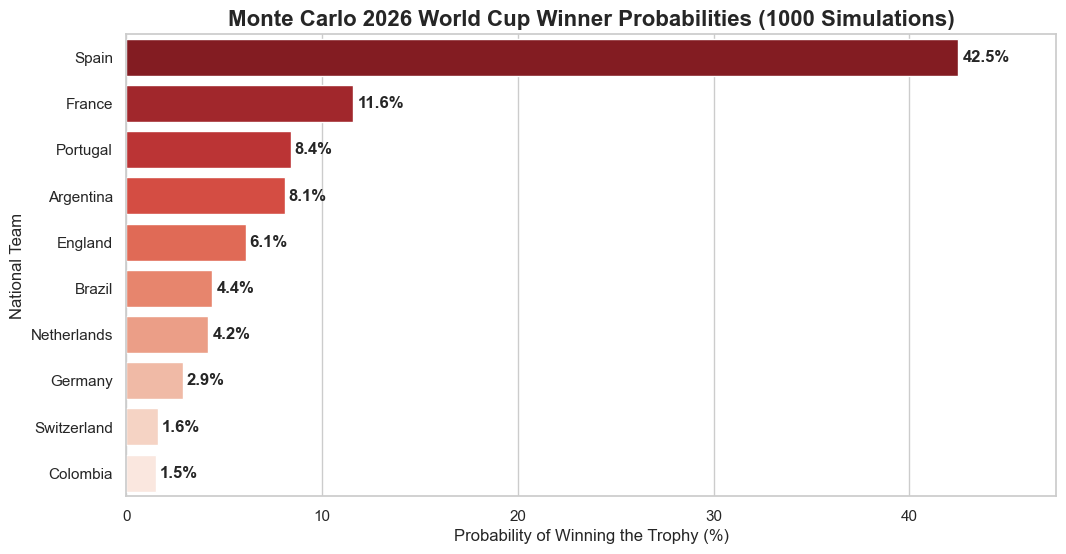

In [50]:
# Number of times to simulate the entire World Cup
SIMULATIONS = 1000
champions = []

print(f"Starting Monte Carlo Simulation ({SIMULATIONS} iterations)...")

# We use the XGBoost model as our champion model
prod_model = trained_models["XGBoost"]

for i in range(SIMULATIONS):
    if i % 100 == 0 and i > 0:
        print(f"Completed {i} tournaments...")
        
    champ = simulate_tournament(future, prod_model)
    champions.append(champ)

print("Simulations complete!")

# Calculate win probabilities
champ_counts = pd.Series(champions).value_counts().reset_index()
champ_counts.columns = ['Team', 'Championships']
champ_counts['Win Probability (%)'] = (champ_counts['Championships'] / SIMULATIONS) * 100

# Visualize the Top 10 most likely winners
top_10 = champ_counts.head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_10, x='Win Probability (%)', y='Team', palette='Reds_r')
plt.title(f'Monte Carlo 2026 World Cup Winner Probabilities ({SIMULATIONS} Simulations)', fontsize=16, fontweight='bold')
plt.xlabel('Probability of Winning the Trophy (%)', fontsize=12)
plt.ylabel('National Team', fontsize=12)
for index, value in enumerate(top_10['Win Probability (%)']):
    plt.text(value + 0.2, index, f'{value:.1f}%', va='center', fontweight='bold')
plt.xlim(0, top_10['Win Probability (%)'].max() + 5)
plt.show()

## Phase 5: The Matchup Explorer (Interpretability)
A professional machine learning project must be explainable. In this final phase, we build a `analyze_matchup` tool. 

You can input any two national teams, and this function will:
1. Extract their most recent, up-to-date statistics.
2. Feed them into our champion XGBoost model.
3. Output the exact win probabilities.
4. Generate a side-by-side visual comparison of their core metrics to explain *why* the model favors one team over the other.

In [51]:
def analyze_matchup(home_team, away_team, model):
    """
    Generates a comprehensive scouting report and visual comparison for any two teams.
    """
    # 1. Fetch current stats
    def get_stat(team, stat):
        return current_stats.get(team, {}).get(stat, 1500 if stat=='elo' else 60 if stat=='squad' else 0)

    h_elo = get_stat(home_team, 'elo')
    a_elo = get_stat(away_team, 'elo')
    h_squad = get_stat(home_team, 'squad')
    a_squad = get_stat(away_team, 'squad')
    h_form = get_stat(home_team, 'form')
    a_form = get_stat(away_team, 'form')
    h_gd = get_stat(home_team, 'gd')
    a_gd = get_stat(away_team, 'gd')
    
    # 2. Calculate differentials for the model
    elo_diff = h_elo - a_elo
    squad_diff = h_squad - a_squad
    hosts = ['United States', 'Mexico', 'Canada']
    host_adv = 1 if home_team in hosts else 0
    
    # 3. Predict Probabilities
    X_match = pd.DataFrame([[elo_diff, host_adv, h_form, a_form, h_gd, a_gd, squad_diff]], columns=features)
    probs = model.predict_proba(X_match)[0]
    
    # 4. Print the Scouting Report
    print("="*50)
    print(f"🏆 MATCHUP REPORT: {home_team} vs {away_team} 🏆")
    print("="*50)
    if host_adv == 1:
        print(f"* Note: {home_team} has Home Field Advantage.")
        
    print(f"\n[ Win Probabilities ]")
    print(f"• {home_team} Win:  {probs[2]*100:.1f}%")
    print(f"• Draw:        {probs[1]*100:.1f}%")
    print(f"• {away_team} Win:  {probs[0]*100:.1f}%\n")
    
    # 5. Visual Comparison
    # We normalize the stats slightly so they fit nicely on the same bar chart scale
    # (e.g., Elo is in the 1500s, Form is 0.0-1.0, so we use separate subplots)
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f'Head-to-Head Metric Comparison: {home_team} vs {away_team}', fontsize=16, fontweight='bold')
    
    # Subplot 1: Elo Rating (Historical Success)
    sns.barplot(ax=axes[0], x=[home_team, away_team], y=[h_elo, a_elo], palette=['#1f77b4', '#ff7f0e'])
    axes[0].set_title('Elo Rating (Overall Strength)')
    axes[0].set_ylim(1200, max(h_elo, a_elo) + 100)
    
    # Subplot 2: Squad Quality (Raw FC 26 Talent)
    sns.barplot(ax=axes[1], x=[home_team, away_team], y=[h_squad, a_squad], palette=['#1f77b4', '#ff7f0e'])
    axes[1].set_title('Squad Quality Index (Top 23 Avg)')
    axes[1].set_ylim(50, 90)
    
    # Subplot 3: Recent Form (Win % last 5 games)
    sns.barplot(ax=axes[2], x=[home_team, away_team], y=[h_form*100, a_form*100], palette=['#1f77b4', '#ff7f0e'])
    axes[2].set_title('Recent Form (Win % over last 5)')
    axes[2].set_ylim(0, 100)
    
    plt.tight_layout()
    plt.show()

### Let's Test It!
We can now use our tool to investigate specific highly-anticipated matches. Let's look at a potential knockout stage clash between a historic powerhouse and a rising team.

🏆 MATCHUP REPORT: Argentina vs Spain 🏆

[ Win Probabilities ]
• Argentina Win:  9.8%
• Draw:        29.9%
• Spain Win:  60.3%



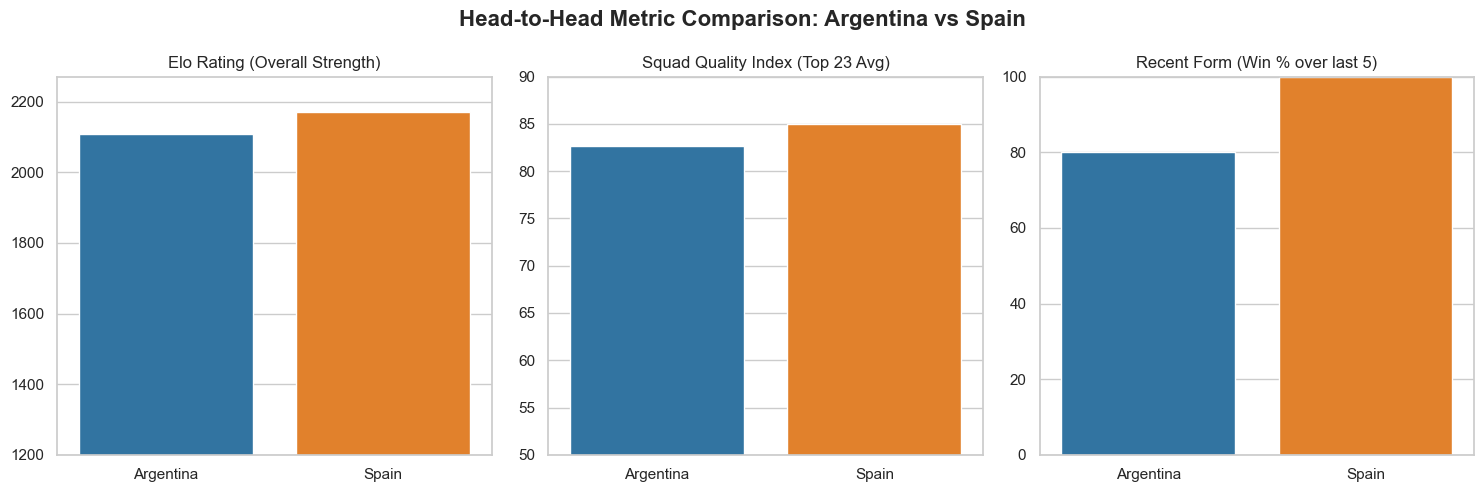

🏆 MATCHUP REPORT: Argentina vs Uruguay 🏆

[ Win Probabilities ]
• Argentina Win:  59.0%
• Draw:        23.0%
• Uruguay Win:  18.0%



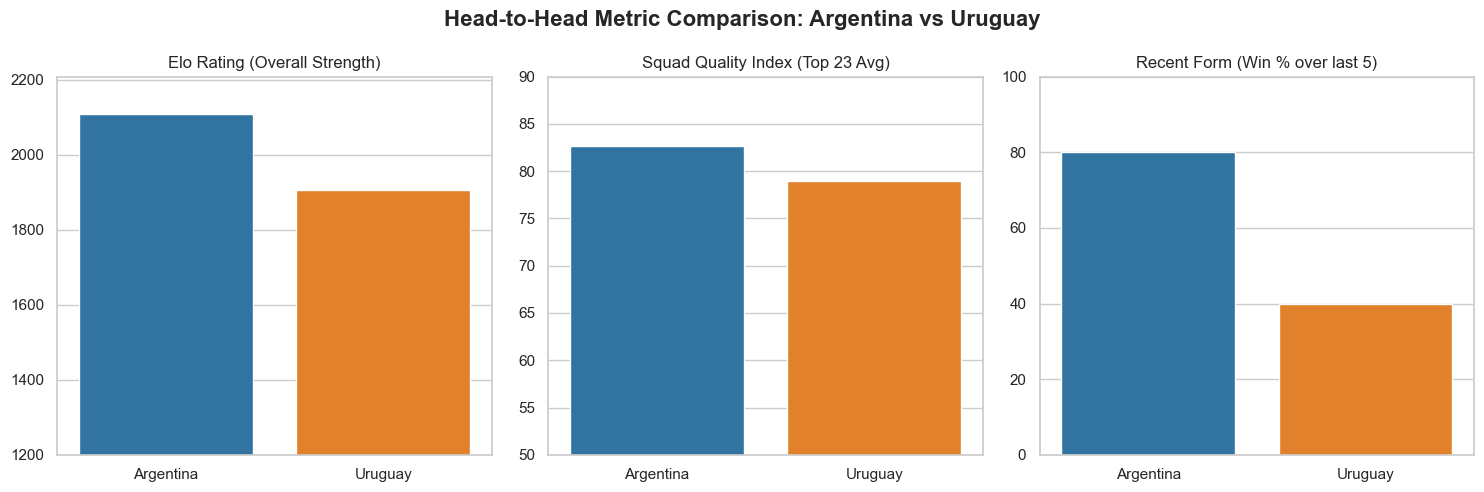

In [54]:
# Try testing a few interesting matchups! 
# Ensure the model variable matches the name of your trained XGBoost model.
prod_model = trained_models["XGBoost"]

# Example 1: A massive heavyweight clash
analyze_matchup("Argentina", "Spain", prod_model)

# Example 2: Testing the North American Host Advantage
analyze_matchup("Argentina", "Uruguay", prod_model)

## Phase 6: The "Chalk" Bracket Visualization
While the Monte Carlo simulation gives us overall probabilities, we want to visualize the model's single most likely path for the tournament. 

We will extract the Top 32 teams based on our current stats, randomize their seeding into a bracket, and then simulate a strictly deterministic knockout stage. In this version, no "upsets" are allowed by the random number generator; the team with the mathematically higher probability from our XGBoost model advances automatically, allowing us to map the "Chalk" bracket.

In [60]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def generate_official_chalk_bracket(model, future_schedule):
    """
    Simulates the group stage, grabs the 1st, 2nd, and 3rd place teams, 
    and hardcodes them into the EXACT slots designated by the 2026 FIFA rulebook.
    """
    points = {team: 0 for team in pd.concat([future_schedule['home_team'], future_schedule['away_team']]).unique()}
    
    def get_stat(team, stat):
        return current_stats.get(team, {}).get(stat, 1500 if stat=='elo' else 60 if stat=='squad' else 0)

    # 1. PLAY THE GROUP STAGE
    for _, row in future_schedule.iterrows():
        team_a, team_b = row['home_team'], row['away_team']
        elo_diff = get_stat(team_a, 'elo') - get_stat(team_b, 'elo')
        squad_diff = get_stat(team_a, 'squad') - get_stat(team_b, 'squad')
        h_form, a_form = get_stat(team_a, 'form'), get_stat(team_b, 'form')
        h_gd, a_gd = get_stat(team_a, 'gd'), get_stat(team_b, 'gd')
        host_adv = 1 if team_a in ['United States', 'Mexico', 'Canada'] else 0
        
        X_match = pd.DataFrame([[elo_diff, host_adv, h_form, a_form, h_gd, a_gd, squad_diff]], columns=features)
        probs = model.predict_proba(X_match)[0]
        
        best_outcome = np.argmax(probs)
        if best_outcome == 2: points[team_a] += 3
        elif best_outcome == 1: points[team_a] += 1; points[team_b] += 1
        else: points[team_b] += 3

    # 2. LOCK IN THE GROUP PLACEMENTS
    placements = {}
    thirds = []
    
    for group_name in sorted(future_schedule['group'].unique()):
        group_data = future_schedule[future_schedule['group'] == group_name]
        group_teams = pd.concat([group_data['home_team'], group_data['away_team']]).unique()
        
        # Sort by Points, then Elo as tiebreaker
        ranked = sorted(group_teams, key=lambda x: (points[x], get_stat(x, 'elo')), reverse=True)
        placements[f'1{group_name}'] = ranked[0]
        placements[f'2{group_name}'] = ranked[1]
        thirds.append((ranked[2], points[ranked[2]], get_stat(ranked[2], 'elo')))
        
    # Sort out the 8 Best Third-Place Teams
    best_thirds = sorted(thirds, key=lambda x: (x[1], x[2]), reverse=True)[:8]
    third_teams = [t[0] for t in best_thirds]
    
    # 3. THE OFFICIAL FIFA ROUND OF 32 MATCHUPS
    # These are hardcoded to match the exact paths (Matches 73-88) leading to the Final
    round_32_ordered = [
        (placements['1E'], third_teams[0]),   # Match 74
        (placements['1I'], third_teams[1]),   # Match 77
        (placements['2A'], placements['2B']), # Match 73
        (placements['1F'], placements['2C']), # Match 75
        (placements['2K'], placements['2L']), # Match 83
        (placements['1H'], placements['2J']), # Match 84
        (placements['1D'], third_teams[2]),   # Match 81
        (placements['1G'], third_teams[3]),   # Match 82
        (placements['1C'], placements['2F']), # Match 76
        (placements['2E'], placements['2I']), # Match 78
        (placements['1A'], third_teams[4]),   # Match 79
        (placements['1L'], third_teams[5]),   # Match 80
        (placements['1J'], placements['2H']), # Match 86 (Argentina's official slot!)
        (placements['2D'], placements['2G']), # Match 88
        (placements['1B'], third_teams[6]),   # Match 85
        (placements['1K'], third_teams[7])    # Match 87
    ]
    
    # 4. SIMULATE THE BRACKET TO THE FINAL
    bracket_data = []
    current_round_pairs = round_32_ordered
    
    while len(current_round_pairs) > 0:
        next_round_teams = []
        round_results = []
        
        for team_a, team_b in current_round_pairs:
            elo_diff = get_stat(team_a, 'elo') - get_stat(team_b, 'elo')
            squad_diff = get_stat(team_a, 'squad') - get_stat(team_b, 'squad')
            h_form, a_form = get_stat(team_a, 'form'), get_stat(team_b, 'form')
            h_gd, a_gd = get_stat(team_a, 'gd'), get_stat(team_b, 'gd')
            host_adv = 1 if team_a in ['United States', 'Mexico', 'Canada'] else 0
            
            X_match = pd.DataFrame([[elo_diff, host_adv, h_form, a_form, h_gd, a_gd, squad_diff]], columns=features)
            probs = model.predict_proba(X_match)[0]
            
            prob_home = float(probs[2] / (probs[0] + probs[2]))
            prob_away = 1.0 - prob_home
            
            if prob_home >= prob_away:
                winner, win_prob = team_a, prob_home
            else:
                winner, win_prob = team_b, prob_away
                
            round_results.append({'team_a': team_a, 'team_b': team_b, 'winner': winner, 'prob': win_prob})
            next_round_teams.append(winner)
            
        bracket_data.append(round_results)
        
        if len(next_round_teams) > 1:
            current_round_pairs = [(next_round_teams[i], next_round_teams[i+1]) for i in range(0, len(next_round_teams), 2)]
        else:
            current_round_pairs = []
            
    return bracket_data, next_round_teams[0]

# Generate the strictly official bracket
prod_model = trained_models["XGBoost"]
bracket_data, champion = generate_official_chalk_bracket(prod_model, future)
print(f"Official FIFA Bracket data generated! Predicted Champion: {champion}")

Official FIFA Bracket data generated! Predicted Champion: Spain


### 6.1 Rendering the Bracket
Using custom `matplotlib` coordinates to draw the matches, lines, and predicted win percentages.

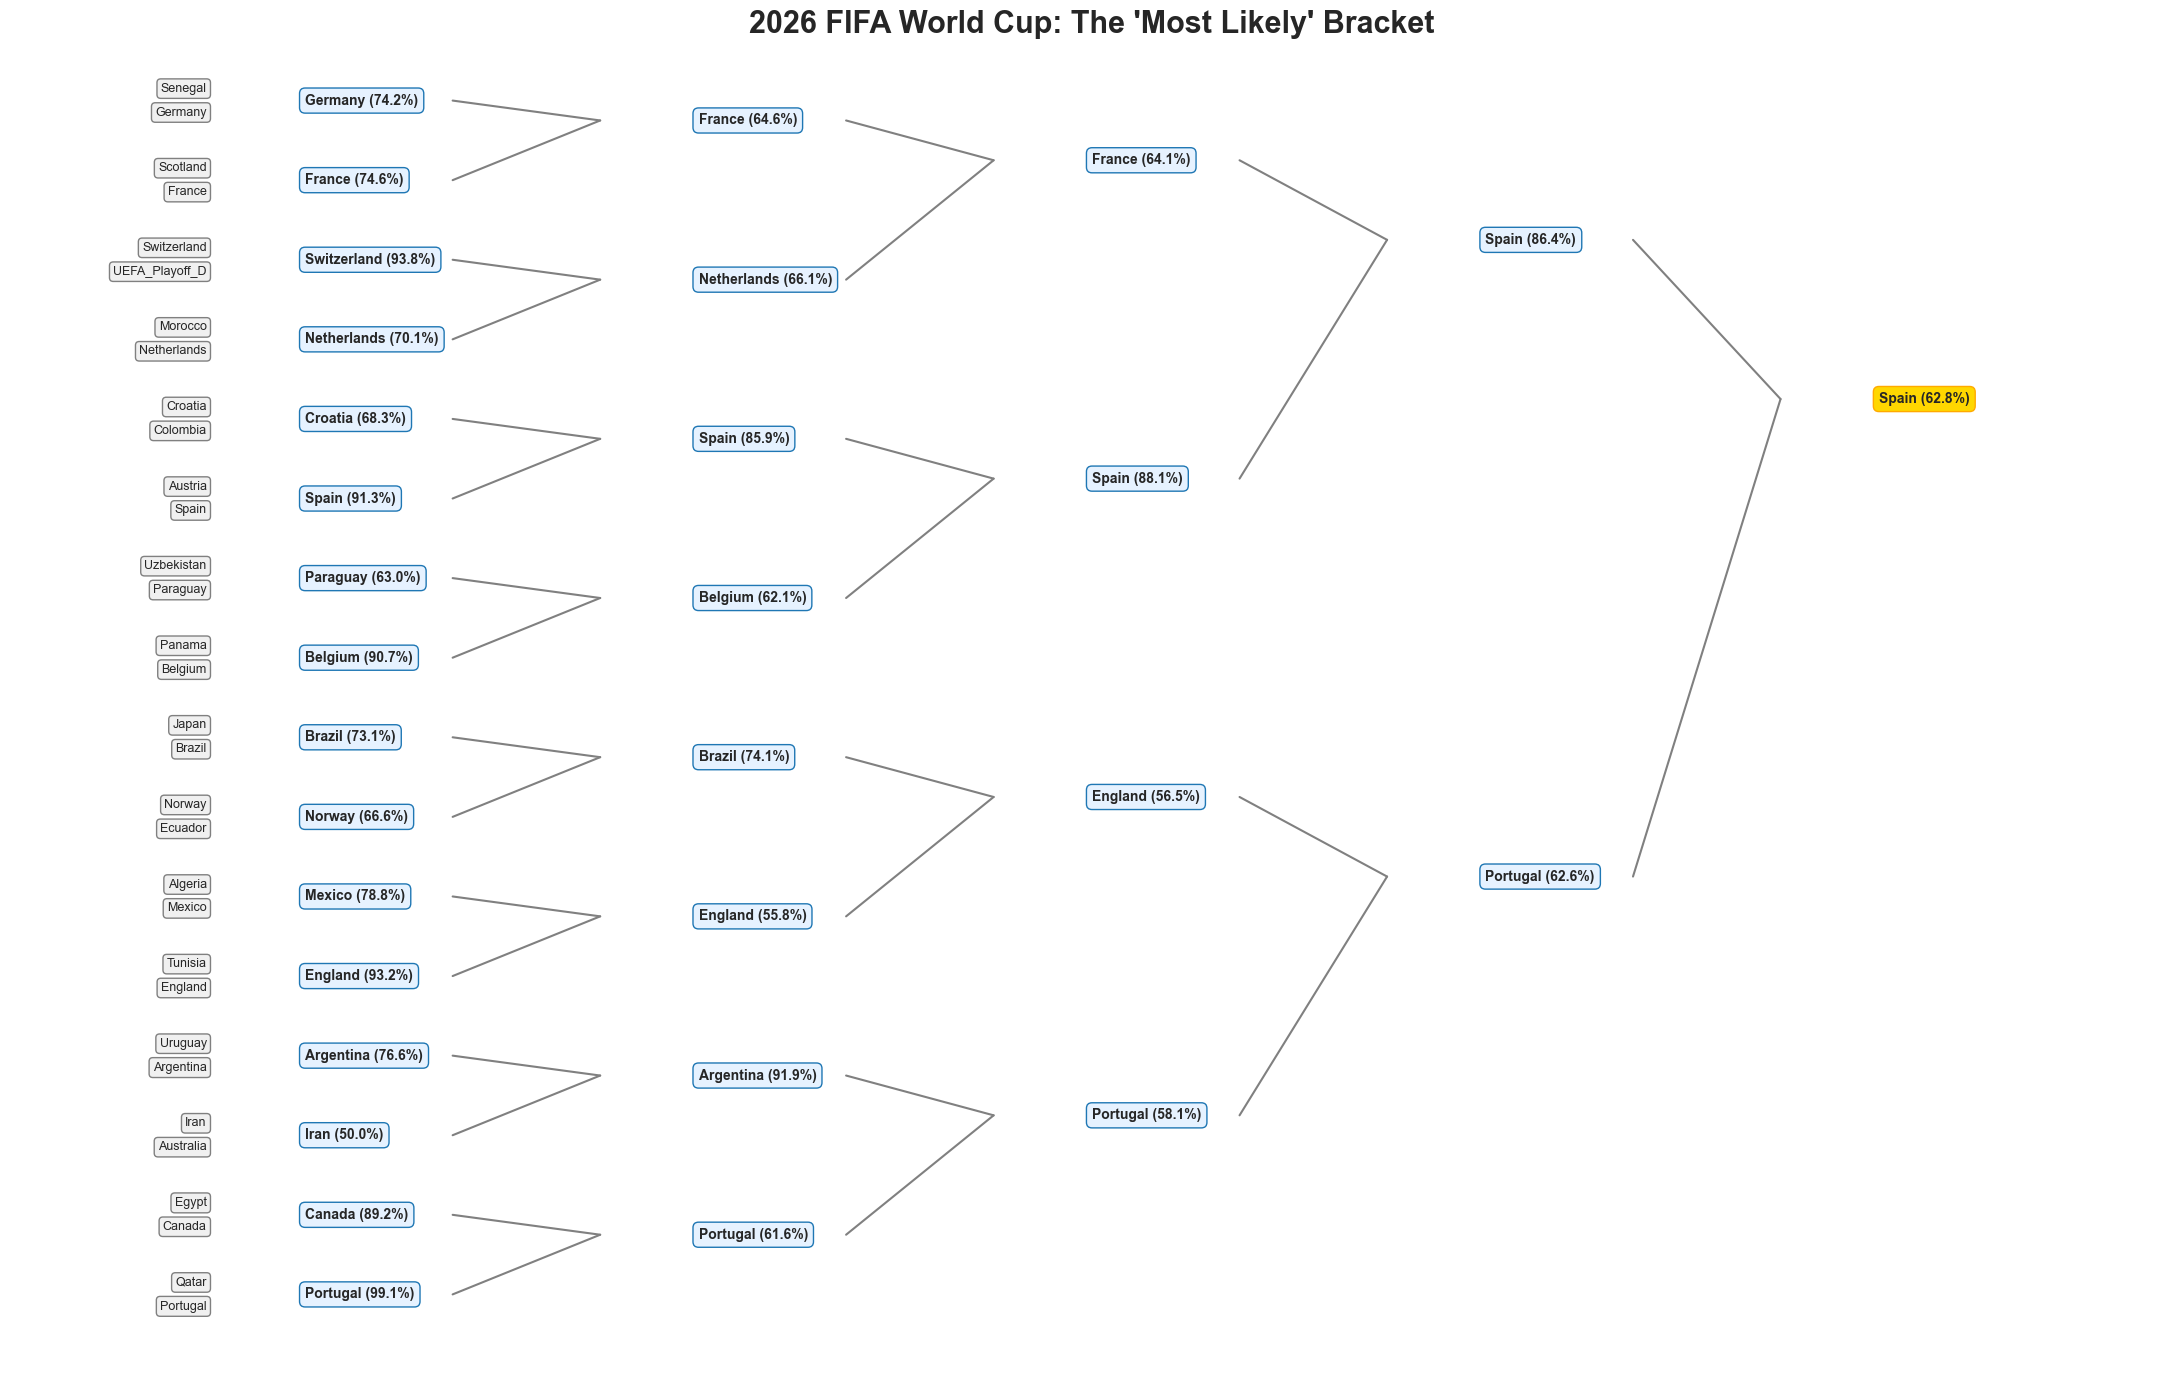

In [61]:
def draw_bracket(bracket_data, champion):
    """
    Uses Matplotlib to draw a left-to-right tree diagram of the tournament bracket.
    """
    fig, ax = plt.subplots(figsize=(22, 14))
    ax.axis('off')
    ax.set_title("2026 FIFA World Cup: The 'Most Likely' Bracket", fontsize=22, fontweight='bold', pad=20)
    
    # Coordinates mapping
    x_spacing = 4
    
    # Store the (x, y) coordinates of the winners to draw lines in the next round
    node_coords = {}
    
    for r_idx, r_matches in enumerate(bracket_data):
        y_spacing = 2 ** r_idx
        y_start = (2 ** r_idx - 1) / 2
        
        for m_idx, match in enumerate(r_matches):
            x = r_idx * x_spacing
            y = y_start + m_idx * (y_spacing * 2)
            
            # Draw Team A and Team B in Round 1 (Round of 32)
            if r_idx == 0:
                ax.text(x, y + 0.3, match['team_a'], va='center', ha='right', fontsize=9, 
                        bbox=dict(facecolor='#f0f0f0', edgecolor='gray', boxstyle='round,pad=0.3'))
                ax.text(x, y - 0.3, match['team_b'], va='center', ha='right', fontsize=9,
                        bbox=dict(facecolor='#f0f0f0', edgecolor='gray', boxstyle='round,pad=0.3'))
            
            # Record coordinates for line drawing
            node_coords[f"r{r_idx}_m{m_idx}"] = (x, y)
            
            # Draw the winner of this match moving forward
            winner_text = f"{match['winner']} ({match['prob']*100:.1f}%)"
            
            # Highlight the ultimate champion in gold
            facecolor = '#ffd700' if match['winner'] == champion and r_idx == 4 else '#e6f2ff'
            edgecolor = '#ffaa00' if match['winner'] == champion and r_idx == 4 else '#1f77b4'
            
            ax.text(x + 1, y, winner_text, va='center', ha='left', fontsize=10, fontweight='bold',
                    bbox=dict(facecolor=facecolor, edgecolor=edgecolor, boxstyle='round,pad=0.4'))
            
            # Draw lines connecting previous round to this match
            if r_idx > 0:
                # Previous match 1 (top branch)
                prev_x1, prev_y1 = node_coords[f"r{r_idx-1}_m{m_idx*2}"]
                # Previous match 2 (bottom branch)
                prev_x2, prev_y2 = node_coords[f"r{r_idx-1}_m{m_idx*2+1}"]
                
                # Draw lines from previous winners to current match
                ax.plot([prev_x1 + 2.5, x], [prev_y1, y], color='gray', linestyle='-', linewidth=1.5, zorder=1)
                ax.plot([prev_x2 + 2.5, x], [prev_y2, y], color='gray', linestyle='-', linewidth=1.5, zorder=1)

    # Adjust layout
    plt.xlim(-2, x_spacing * 5)
    plt.ylim(-1, len(bracket_data[0]) * 2)
    plt.gca().invert_yaxis() # Put match 1 at the top
    plt.tight_layout()
    plt.show()

# Render the final image!
draw_bracket(bracket_data, champion)

🏆 MATCHUP REPORT: Argentina vs Portugal 🏆

[ Win Probabilities ]
• Argentina Win:  29.6%
• Draw:        29.3%
• Portugal Win:  41.1%



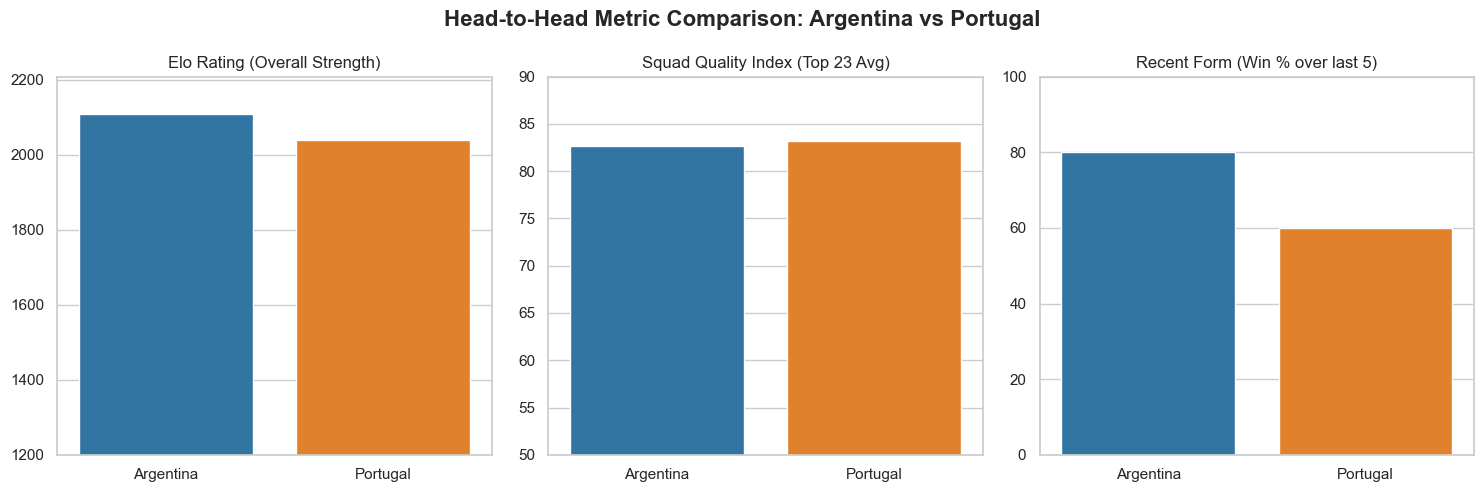

In [62]:
analyze_matchup("Argentina", "Portugal", prod_model)